In [1]:
import pandas as pd

df= pd.read_csv("ai_student_impact_dataset.csv")

info=df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

ossevare corr votazione, incremento, skill retention e burnout
Major_Category -> più colonne?
Year_of_Study -> diventa int 
Primary_Use_Case -> più colonne?
Prompt_Engineering_Skill -> int
Institutional_Policy -> int


In [2]:
df["GPA_increment"] = df["Post_Semester_GPA"]- df["Pre_Semester_GPA"]

In [3]:
df.value_counts(df["Burnout_Risk_Level"])
trad={"Low":1,"Medium":2,"High":3}
df["Burnout_Risk_Level"]=df["Burnout_Risk_Level"].map(trad)

In [4]:
df[["Burnout_Risk_Level","GPA_increment","Post_Semester_GPA","Skill_Retention_Score"]].corr()

,Burnout_Risk_Level,GPA_increment,Post_Semester_GPA,Skill_Retention_Score
Burnout_Risk_Level,1.000000,-0.006818,-0.095543,-0.058140
GPA_increment,-0.006818,1.000000,0.277146,0.195833
Post_Semester_GPA,-0.095543,0.277146,1.000000,0.169616
Skill_Retention_Score,-0.058140,0.195833,0.169616,1.000000


togliamo ora il target e info su Burnout e Skill Retention

In [5]:
y= df["GPA_increment"].copy()
df.drop(columns=["Burnout_Risk_Level","Skill_Retention_Score"], inplace=True)

In [6]:
df.drop(columns="Student_ID",inplace=True)

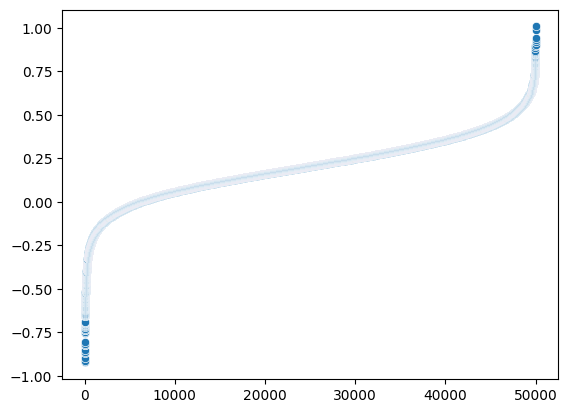

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

x=[]
y=[]

for i, incr in enumerate(df["GPA_increment"].sort_values()):
    x.append(i)
    y.append(incr)


sns.scatterplot(x=x,y=y)
plt.show()


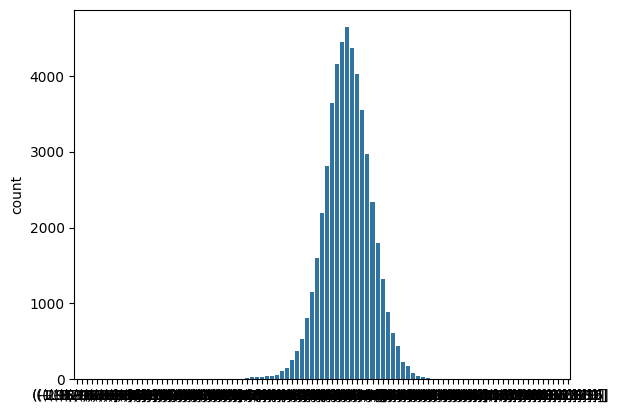

In [8]:

gruppi = pd.cut(y, np.linspace(-2,2,100))

sns.countplot(x=gruppi)
plt.show()


In [9]:
df.value_counts(df["Major_Category"])

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

fare modelli diversi per percorsi diversi?

In [10]:
trad={
"Junior": 3 ,
"Freshman" : 1,
"Senior"  : 4, 
"Sophomore"  : 2,
"Graduate" : 5,
}

df["Year_of_Study"]=df["Year_of_Study"].map(trad)

print(df["Year_of_Study"].unique())

[4 3 1 2 5]


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  str    
 1   Year_of_Study               50000 non-null  int64  
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  str    
 5   Prompt_Engineering_Skill    50000 non-null  str    
 6   Tool_Diversity              50000 non-null  int64  
 7   Paid_Subscription           50000 non-null  bool   
 8   Traditional_Study_Hours     50000 non-null  float64
 9   Perceived_AI_Dependency     50000 non-null  int64  
 10  Institutional_Policy        50000 non-null  str    
 11  Anxiety_Level_During_Exams  50000 non-null  int64  
 12  Post_Semester_GPA           50000 non-null  float64
 13  GPA_increment               50000 non-null

In [12]:
for use in df["Primary_Use_Case"].unique():
    df["is_"+use]= df["Primary_Use_Case"]==use

df.drop(columns="Primary_Use_Case",inplace=True)

In [13]:
df.value_counts(df["Prompt_Engineering_Skill"])

Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

In [14]:
trad={
"Beginner": 1 ,
"Intermediate" : 2,
"Advanced"  : 3, 
}

df["Prompt_Engineering_Skill"]=df["Prompt_Engineering_Skill"].map(trad)

print(df["Prompt_Engineering_Skill"].unique())

[1 3 2]


In [15]:

df.value_counts(df["Institutional_Policy"])

Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

In [16]:
for corso in df["Institutional_Policy"].unique():
    df["is_"+corso]= df["Institutional_Policy"]==corso

df.drop(columns="Institutional_Policy",inplace=True)

primo approccio mantenere categorie tutte assieme nello stesso dataset ma in colonne diverse e vediamo (poi dopo proviamo a dividere dataset per fare 5 modelli diversi)

In [17]:
df_by_category = df.copy() #salvo una copia del dataset per poi usarlo dopo per creare modelli separati

In [18]:
for corso in df["Major_Category"].unique():
    df["major_is_"+corso]= df["Major_Category"]==corso

df.drop(columns="Major_Category",inplace=True)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

df.drop(columns="GPA_increment",inplace=True,errors=True)
# X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)

modello baseline

In [20]:
from xgboost import XGBRegressor

# rf_model = XGBRegressor(
#     n_estimators=100,
#     random_state=42
# )


# rf_model.fit(X_train, y_train) 

In [21]:
# predictions = rf_model.predict(X_test)

# print(mean_absolute_error(y_test, predictions))

# print(r2_score(y_test, predictions))

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year_of_Study                 50000 non-null  int64  
 1   Pre_Semester_GPA              50000 non-null  float64
 2   Weekly_GenAI_Hours            50000 non-null  float64
 3   Prompt_Engineering_Skill      50000 non-null  int64  
 4   Tool_Diversity                50000 non-null  int64  
 5   Paid_Subscription             50000 non-null  bool   
 6   Traditional_Study_Hours       50000 non-null  float64
 7   Perceived_AI_Dependency       50000 non-null  int64  
 8   Anxiety_Level_During_Exams    50000 non-null  int64  
 9   Post_Semester_GPA             50000 non-null  float64
 10  is_Copywriting/Drafting       50000 non-null  bool   
 11  is_Ideation                   50000 non-null  bool   
 12  is_Summarizing_Reading        50000 non-null  bool   
 13  is_Debugging

In [23]:
# un dataframe per ogni categoria
df_dict={
    k:df_by_category[df_by_category["Major_Category"] == k]  for k in df_by_category["Major_Category"].unique()
}


In [24]:
for d in df_dict.values():
    d.drop(columns=["Major_Category"], inplace=True)
    d.drop(columns=["GPA_increment"], inplace=True)
d.info()

df_dict["Tutti i major"]=df


<class 'pandas.DataFrame'>
Index: 5933 entries, 7 to 49999
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year_of_Study                 5933 non-null   int64  
 1   Pre_Semester_GPA              5933 non-null   float64
 2   Weekly_GenAI_Hours            5933 non-null   float64
 3   Prompt_Engineering_Skill      5933 non-null   int64  
 4   Tool_Diversity                5933 non-null   int64  
 5   Paid_Subscription             5933 non-null   bool   
 6   Traditional_Study_Hours       5933 non-null   float64
 7   Perceived_AI_Dependency       5933 non-null   int64  
 8   Anxiety_Level_During_Exams    5933 non-null   int64  
 9   Post_Semester_GPA             5933 non-null   float64
 10  is_Copywriting/Drafting       5933 non-null   bool   
 11  is_Ideation                   5933 non-null   bool   
 12  is_Summarizing_Reading        5933 non-null   bool   
 13  is_Debugging/Troub

In [25]:
def make_primary_use_case_dict(X,y):
    dictionary={}
    
    for use in X["Primary_Use_Case"].unique():
        # estra in base a use case i solo target corrispondenti
        only_use_target=y[X["Primary_Use_Case"]==use]
        #calcola media poi lo mette nel dizionario
        dictionary[use]=np.mean(only_use_target)

    return dictionary


In [26]:
model_params_major_dict={}

import optuna

def objective(trial):

    data= df_dict[corso]
    y=data["Post_Semester_GPA"]
    X=data.drop(columns='Post_Semester_GPA')

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'tree_method': 'hist',
        'enable_categorical':True,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
        'bootstrap_type': "Bayesian",
        
       
        'n_estimators': trial.suggest_int('n_estimators', 50, 250),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3,18),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True)
    }

    if params["bootstrap_type"] == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif params["bootstrap_type"] == "Bernoulli":
        params["subsample"] = trial.suggest_float("subsample", 0.1, 1)

    model = XGBRegressor(**params)
    #FEATURE ENG irrilevante 
    # use_case_dict=make_primary_use_case_dict(X_train,y_train)

    # X_train["Primary_Use_Case"]=X_train["Primary_Use_Case"].map(use_case_dict)
    # X_test["Primary_Use_Case"]=X_test["Primary_Use_Case"].map(use_case_dict)
    

    model.fit(X_train, y_train,verbose=1)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    return mae


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
best_model_major_dict={}
import seaborn as sns
for corso in df_dict.keys():
    
    print(f"major {corso}")
    c=corso

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100, timeout=600)

    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))
    
    optimal_params = study.best_trial.params
    model_params_major_dict[corso]=optimal_params
    model=XGBRegressor(**optimal_params)
    data= df_dict[corso]
    y=data["Post_Semester_GPA"]
    X=data.drop(columns='Post_Semester_GPA')

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # use_case_dict=make_primary_use_case_dict(X_train,y_train)

    # X_train["Primary_Use_Case"]=X_train["Primary_Use_Case"].map(use_case_dict)
    # X_test["Primary_Use_Case"]=X_test["Primary_Use_Case"].map(use_case_dict)
    
    model.fit(X_train,y_train)
    preds = model.predict(X_test)

    print("business mae:", mean_absolute_error(y_test, preds))
    print("business r2:", r2_score(y_test, preds))
    best_model_major_dict[corso]=model    


[I 2026-06-08 12:09:18,021] A new study created in memory with name: no-name-507e2994-f6f8-4eaf-ad66-a6135866eab0


major Humanities


[I 2026-06-08 12:09:18,405] Trial 0 finished with value: 0.2823448332681126 and parameters: {'n_estimators': 250, 'learning_rate': 0.002799945941252853, 'max_depth': 10, 'subsample': 0.9415405110309348, 'colsample_bytree': 0.7023624535478383, 'reg_alpha': 0.8080065741702488, 'bagging_temperature': 1.9779393404317802}. Best is trial 0 with value: 0.2823448332681126.
[I 2026-06-08 12:09:18,644] Trial 1 finished with value: 0.26294296347659607 and parameters: {'n_estimators': 116, 'learning_rate': 0.005541988714170591, 'max_depth': 11, 'subsample': 0.8765438201420817, 'colsample_bytree': 0.8779594902553911, 'reg_alpha': 0.005634301279180789, 'bagging_temperature': 9.854570481549656}. Best is trial 1 with value: 0.26294296347659607.
[I 2026-06-08 12:09:18,712] Trial 2 finished with value: 0.345616030811846 and parameters: {'n_estimators': 104, 'learning_rate': 0.0021392415728766425, 'max_depth': 6, 'subsample': 0.8134621284953414, 'colsample_bytree': 0.9397472174079324, 'reg_alpha': 0.0451

Number of finished trials: 100
Best trial:
  Value: 0.11514979236110441
  Params: 
    n_estimators: 240
    learning_rate: 0.07198169007694769
    max_depth: 3
    subsample: 0.7734839965850162
    colsample_bytree: 0.9848811169668261
    reg_alpha: 0.12917825870304328
    bagging_temperature: 9.529414691723266
business mae: 0.1149097143653156
business r2: 0.9158677342417009
major Medical


[I 2026-06-08 12:09:31,127] Trial 1 finished with value: 0.3079174868663152 and parameters: {'n_estimators': 249, 'learning_rate': 0.0015052734159074319, 'max_depth': 13, 'subsample': 0.6177293567932063, 'colsample_bytree': 0.9905314777472217, 'reg_alpha': 0.318585508687343, 'bagging_temperature': 0.22677987818270906}. Best is trial 0 with value: 0.28010606587521825.
[I 2026-06-08 12:09:31,354] Trial 2 finished with value: 0.20289043865527634 and parameters: {'n_estimators': 232, 'learning_rate': 0.005663621897515837, 'max_depth': 15, 'subsample': 0.8603347055793638, 'colsample_bytree': 0.7789015554943804, 'reg_alpha': 1.5017840555414663, 'bagging_temperature': 8.759526576934844}. Best is trial 2 with value: 0.20289043865527634.
[I 2026-06-08 12:09:31,455] Trial 3 finished with value: 0.13948939174487265 and parameters: {'n_estimators': 148, 'learning_rate': 0.02246463338939761, 'max_depth': 8, 'subsample': 0.7512961297433411, 'colsample_bytree': 0.6902889288109777, 'reg_alpha': 0.0786

...

[I 2026-06-08 12:10:04,989] Trial 0 finished with value: 0.236445467830809 and parameters: {'n_estimators': 181, 'learning_rate': 0.004318793034199242, 'max_depth': 14, 'subsample': 0.8199910120434799, 'colsample_bytree': 0.9778671201737871, 'reg_alpha': 0.09959019899262302, 'bagging_temperature': 1.7069001383806592}. Best is trial 0 with value: 0.236445467830809.
[I 2026-06-08 12:10:05,020] Trial 1 finished with value: 0.3482386999556068 and parameters: {'n_estimators': 70, 'learning_rate': 0.004642160595047311, 'max_depth': 6, 'subsample': 0.6638529945091545, 'colsample_bytree': 0.7337670275589876, 'reg_alpha': 5.562493055805534, 'bagging_temperature': 5.5610224924777025}. Best is trial 0 with value: 0.236445467830809.
[I 2026-06-08 12:10:05,105] Trial 2 finished with value: 0.31970137376632624 and parameters: {'n_estimators': 174, 'learning_rate': 0.0025918492880225067, 'max_depth': 8, 'subsample': 0.7757327172332019, 'colsample_bytree': 0.7162521856738154, 'reg_alpha': 2.3144702389

Number of finished trials: 100
Best trial:
  Value: 0.11875460715161318
  Params: 
    n_estimators: 245
    learning_rate: 0.0695288303120799
    max_depth: 3
    subsample: 0.6807226049569693
    colsample_bytree: 0.8164465692119054
    reg_alpha: 0.005088480968844545
    bagging_temperature: 4.923041127489163
business mae: 0.11934218569613346
business r2: 0.9128156359026892
major Tutti i major


[I 2026-06-08 12:10:16,486] Trial 0 finished with value: 0.3470898227554321 and parameters: {'n_estimators': 196, 'learning_rate': 0.0010319960252407302, 'max_depth': 18, 'subsample': 0.8237641762709373, 'colsample_bytree': 0.8952062014139714, 'reg_alpha': 2.4708024084424283, 'bagging_temperature': 2.149252531006235}. Best is trial 0 with value: 0.3470898227554321.
[I 2026-06-08 12:10:18,438] Trial 1 finished with value: 0.2136719035919189 and parameters: {'n_estimators': 247, 'learning_rate': 0.004472651167155534, 'max_depth': 15, 'subsample': 0.7631123745363514, 'colsample_bytree': 0.765882812583356, 'reg_alpha': 0.3461233788096449, 'bagging_temperature': 3.540404267056739}. Best is trial 1 with value: 0.2136719035919189.
[I 2026-06-08 12:10:18,614] Trial 2 finished with value: 0.35613389162101744 and parameters: {'n_estimators': 139, 'learning_rate': 0.001260453267291862, 'max_depth': 7, 'subsample': 0.6577985009552645, 'colsample_bytree': 0.8349634017967631, 'reg_alpha': 0.00233871

Number of finished trials: 100
Best trial:
  Value: 0.11205913934926985
  Params: 
    n_estimators: 220
    learning_rate: 0.06628178445019706
    max_depth: 5
    subsample: 0.7381619150575034
    colsample_bytree: 0.9687803327445226
    reg_alpha: 2.6353463406048503
    bagging_temperature: 1.9214300733916392
business mae: 0.11187358609609603
business r2: 0.9159211320886068


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:10:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [28]:
df_dict['Tutti i major'].info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year_of_Study                 50000 non-null  int64  
 1   Pre_Semester_GPA              50000 non-null  float64
 2   Weekly_GenAI_Hours            50000 non-null  float64
 3   Prompt_Engineering_Skill      50000 non-null  int64  
 4   Tool_Diversity                50000 non-null  int64  
 5   Paid_Subscription             50000 non-null  bool   
 6   Traditional_Study_Hours       50000 non-null  float64
 7   Perceived_AI_Dependency       50000 non-null  int64  
 8   Anxiety_Level_During_Exams    50000 non-null  int64  
 9   Post_Semester_GPA             50000 non-null  float64
 10  is_Copywriting/Drafting       50000 non-null  bool   
 11  is_Ideation                   50000 non-null  bool   
 12  is_Summarizing_Reading        50000 non-null  bool   
 13  is_Debugging

c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:10:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Humanities mae: 0.1149097143653156
Humanities r2: 0.9158677342417009
Medical mae: 0.11591104030829891
Medical r2: 0.9146490348668661


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:10:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:10:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:10:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Business mae: 0.11534636506509552
Business r2: 0.9075616544464087
STEM mae: 0.11713373758656727
STEM r2: 0.9063527371268049
Arts mae: 0.11934218569613346
Arts r2: 0.9128156359026892


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:10:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:10:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tutti i major mae: 0.11187358609609603
Tutti i major r2: 0.9159211320886068


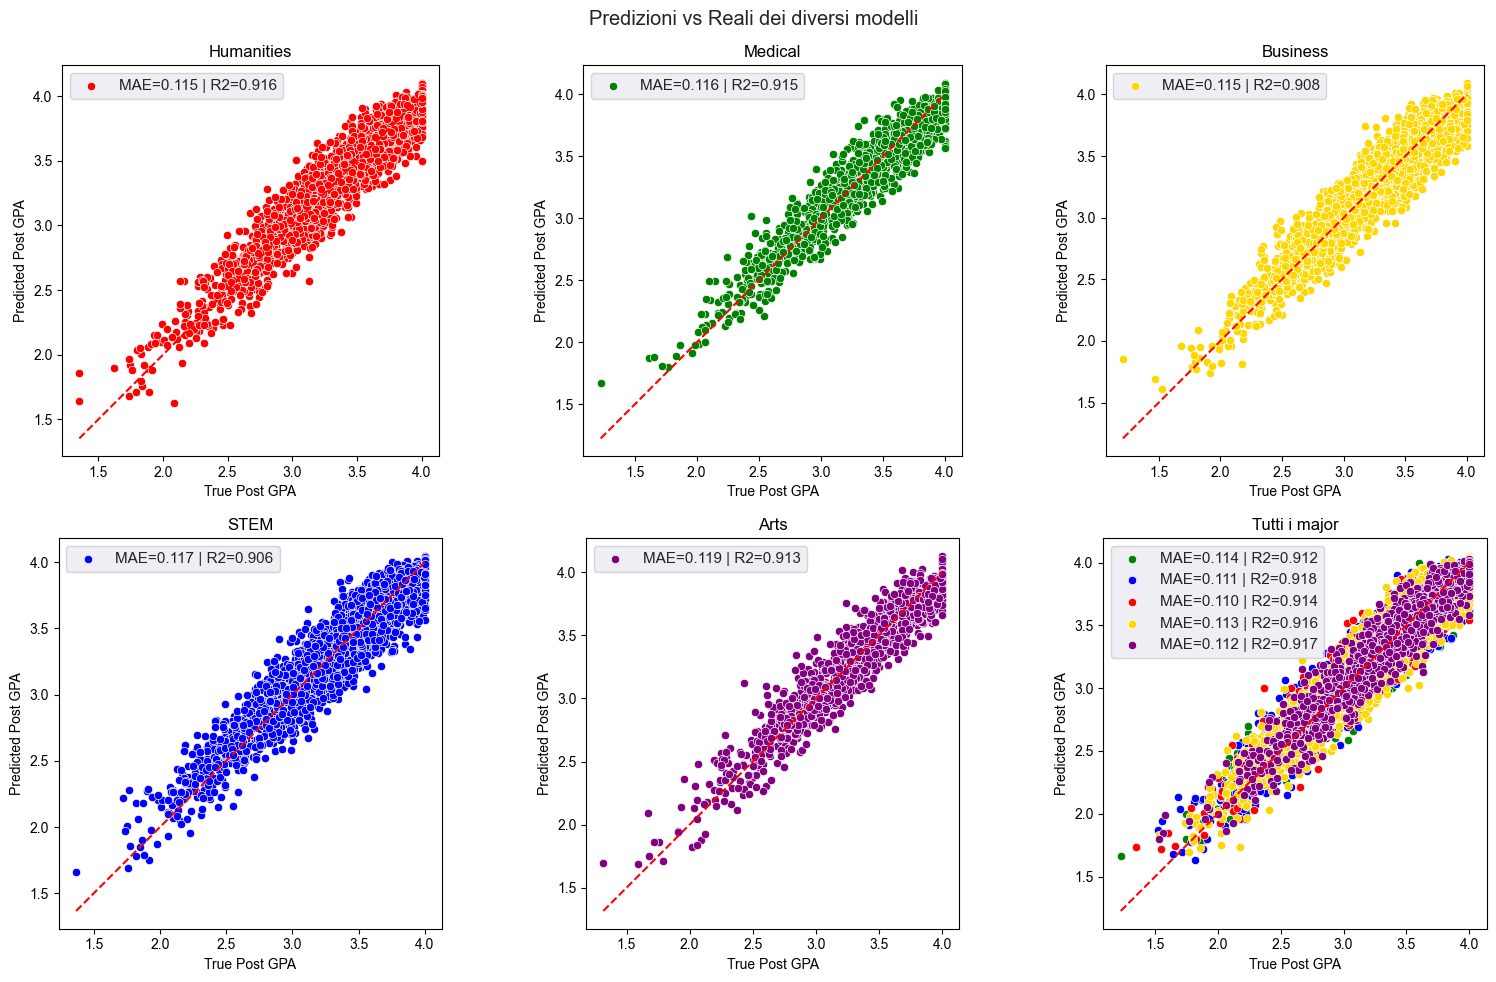

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
sns.set_theme(style='darkgrid')

corso_color = {
    "Medical": "green",
    "STEM": "blue",
    "Humanities": "red",
    "Business": "gold",
    "Arts": "purple"
}

for i, corso in enumerate(df_dict):
    optimal_params = model_params_major_dict[corso]

    model = XGBRegressor(**optimal_params)

    data = df_dict[corso]

    y = data["Post_Semester_GPA"]
    X = data.drop(columns="Post_Semester_GPA")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    # use_case_dict=make_primary_use_case_dict(X_train,y_train)

    # X_train["Primary_Use_Case"]=X_train["Primary_Use_Case"].map(use_case_dict)
    # X_test["Primary_Use_Case"]=X_test["Primary_Use_Case"].map(use_case_dict)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{corso} mae:", mae)
    print(f"{corso} r2:", r2)
    if "Tutti" not in corso:
        sns.scatterplot(
            x=y_test,
            y=preds,
            ax=axes[i],
            c=corso_color[corso],
            label=f"MAE={mae:.3f} | R2={r2:.3f}"
        )
    else:
        real_vs_preds=list(zip(y_test,preds))
    
        for cors in corso_color.keys():
            if "Tutti" in cors:
                continue
            mask= X_test["major_is_"+cors]==True
            tmp=[[e[0],e[1]] for e,m in zip(real_vs_preds,mask) if m]
            
            tmp_real=[e[0] for e in tmp ]
            tmp_pred=[e[1] for e in tmp ]

            mae = mean_absolute_error(tmp_real, tmp_pred)
            r2 = r2_score(tmp_real, tmp_pred)

            sns.scatterplot(
            x=tmp_real,
            y=tmp_pred,
            ax=axes[i],
            c=corso_color[cors],
            label=f"MAE={mae:.3f} | R2={r2:.3f}"
        )


        

    axes[i].set_title(corso)
    axes[i].set_xlabel("True Post GPA")
    axes[i].set_ylabel("Predicted Post GPA")
    axes[i].set_aspect('equal', adjustable='box')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],c='red', linestyle='--',)

    

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Predizioni vs Reali dei diversi modelli")
plt.tight_layout()
plt.show()

In [30]:
corso="Tutti i major"
optimal_params = model_params_major_dict[corso]
model = XGBRegressor(**optimal_params)

data = df_dict[corso]

y = data["Post_Semester_GPA"]
X = data.drop(columns="Post_Semester_GPA")


model.fit(X,y)

c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:10:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9687803327445226
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [31]:
import joblib
filename = 'gpa_model.pkl'
joblib.dump(model, filename=filename) 

['gpa_model.pkl']